# Netflix Filmes e TV Shows - Análise Exploratória


In [247]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import plotly.express as px
import warnings

## Importando o Data Frame

In [177]:
df = pd.read_csv("netflix_titles.csv")

## Verificando os dados faltantes 

In [178]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

## Removendo os valores faltantes

In [179]:
df["title"] = df["title"].fillna("Unkdown")
df["country"] = df["country"].fillna("Unkdown")
df["rating"] = df["rating"].fillna("Unkdown")
df["duration"] =  df["duration"].fillna("Unkdown")


## Verificando o tipo de cada coluna do Dataframe

In [181]:
df.dtypes


show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

## Mudando a coluna para o tipo data (Datetime)

In [182]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

# 1. Distribuição de Filmes vs Tv Show
### Verificando a quantidade de Movies e TV Shows no catálogo

**Objetivo:** Analisar a proporção entre filmes e séries disponíveis na Netflix.

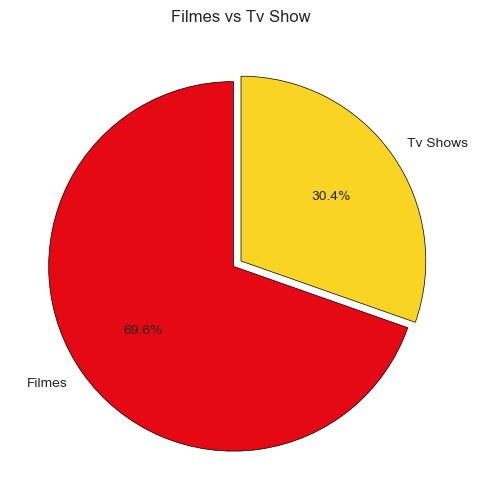

In [271]:
netflix_series = df["type"].value_counts()
plt.figure(figsize=(10,6))
plt.pie(netflix_series, labels=["Filmes", "Tv Shows"], autopct="%1.1f%%", colors=["#E50914", "#f9d423"], startangle=90, explode = (0.05, 0), wedgeprops={'edgecolor': 'black', 'linewidth': 0.5})
plt.title("Filmes vs Tv Show")
plt.show()

## Distribuição Geográfica do Conteúdo
### Análise dos países com mais produções no catálogo da Netflix

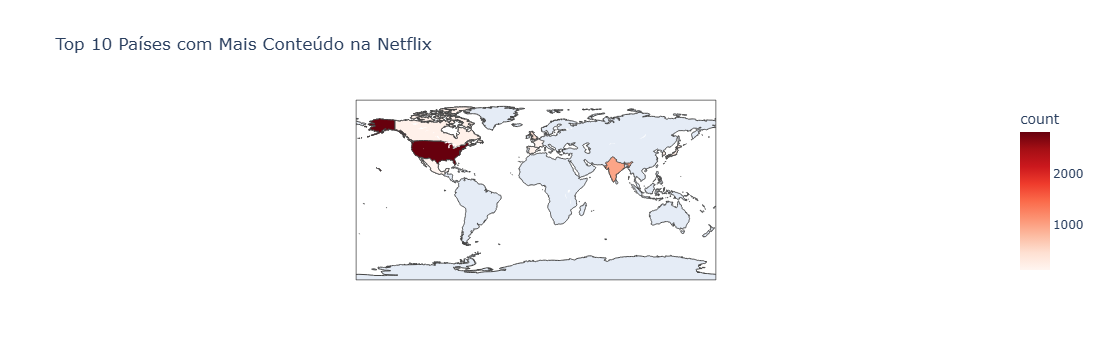

In [253]:

regiao = df["country"].value_counts().head(10).reset_index()
regiao.columns = ['country', 'count']  
fig = px.choropleth(
    regiao,
    locations='country',
    locationmode='country names',
    color='count',
    color_continuous_scale='Reds',
    title='Top 10 Países com Mais Conteúdo na Netflix'
)

fig.show()

## Análise de Classificação Etária

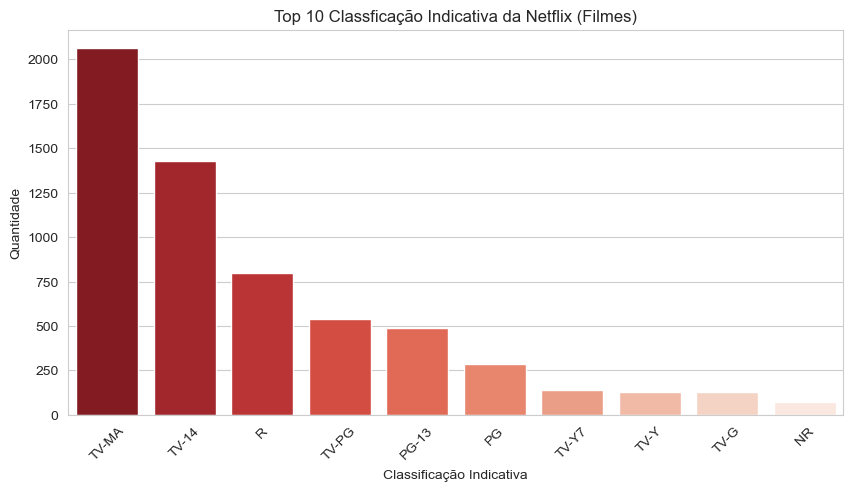

In [255]:
netflix =  df[df["type"]== "Movie"]["rating"].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(y = netflix.values, x = netflix.index, hue=netflix.index,palette="Reds_r")
plt.title("Top 10 Classficação Indicativa da Netflix (Filmes)")
plt.xlabel("Classificação Indicativa")
plt.ylabel("Quantidade")
sns.set_style("whitegrid")
plt.xticks(rotation = 45)
plt.show()


## Top 10 Gêneros Mais Comuns


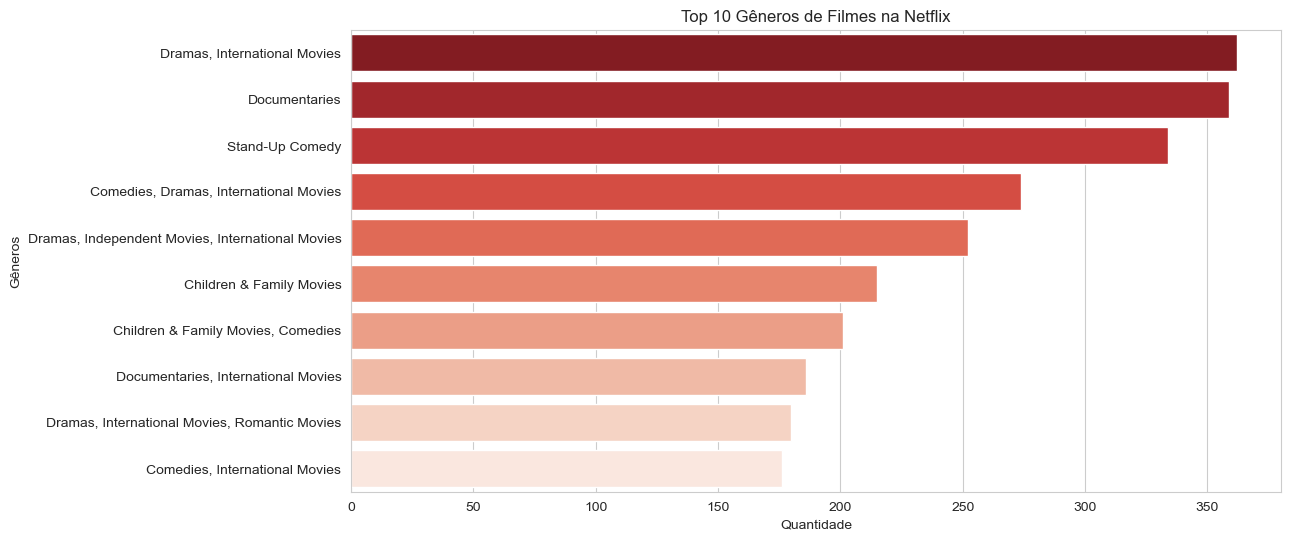

In [254]:
netflix_generos =  df[df["type"]=="Movie"]["listed_in"].value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=netflix_generos.values, y = netflix_generos.index,hue=netflix_generos.index, palette="Reds_r")
plt.title("Top 10 Gêneros de Filmes na Netflix")
plt.xlabel("Quantidade")
plt.ylabel("Gêneros")
plt.show()

## Evolução do Catálogo por Ano
### Visualizando a tendência de crescimento da Netflix

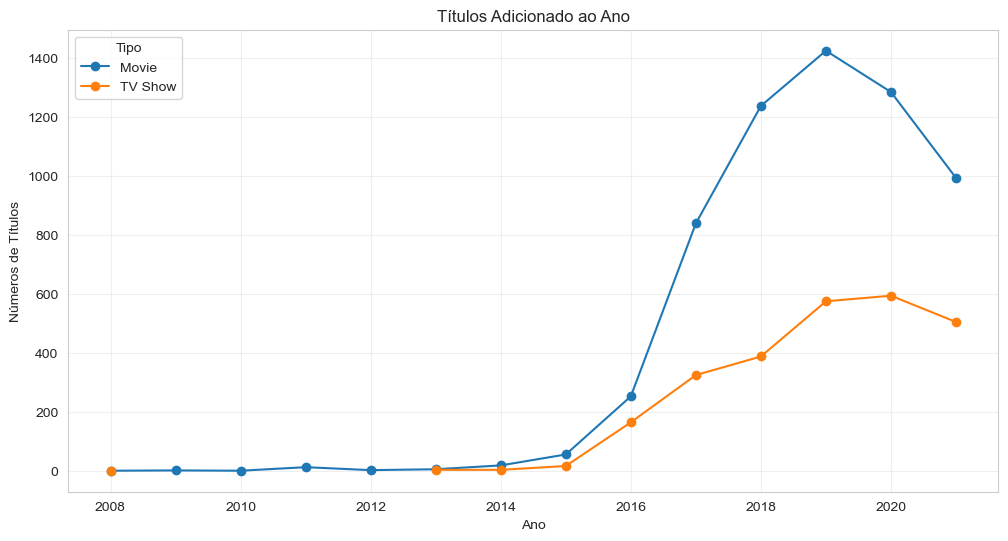

In [233]:
ano = df.groupby([df["date_added"].dt.year, "type"]).size().unstack()
ano.plot(marker="o", figsize=(12, 6))
plt.title("Títulos Adicionado ao Ano")
plt.xlabel("Ano")
plt.ylabel("Números de Títulos")
plt.legend(title="Tipo")
plt.grid(True, alpha=0.3)
plt.show()

## Duração Média dos Filmes por Ano


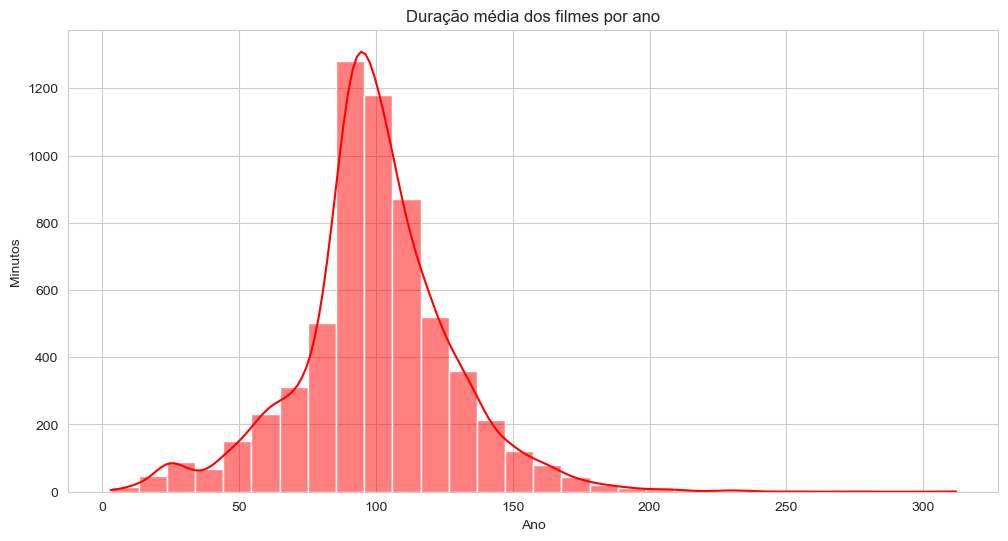

In [210]:
df["duracao"] = df["duration"].str.extract(r"(\d+)").astype(float)
filmes_duracao =  df[df["type"]=="Movie"]
plt.figure(figsize=(12, 6))
sns.histplot(filmes_duracao["duracao"], bins=30, kde=True, color="red")
plt.title("Duração média dos filmes por ano")
plt.xlabel("Ano")
plt.ylabel("Minutos")
plt.show()

## Top 10 Atores com Mais Trabalhos

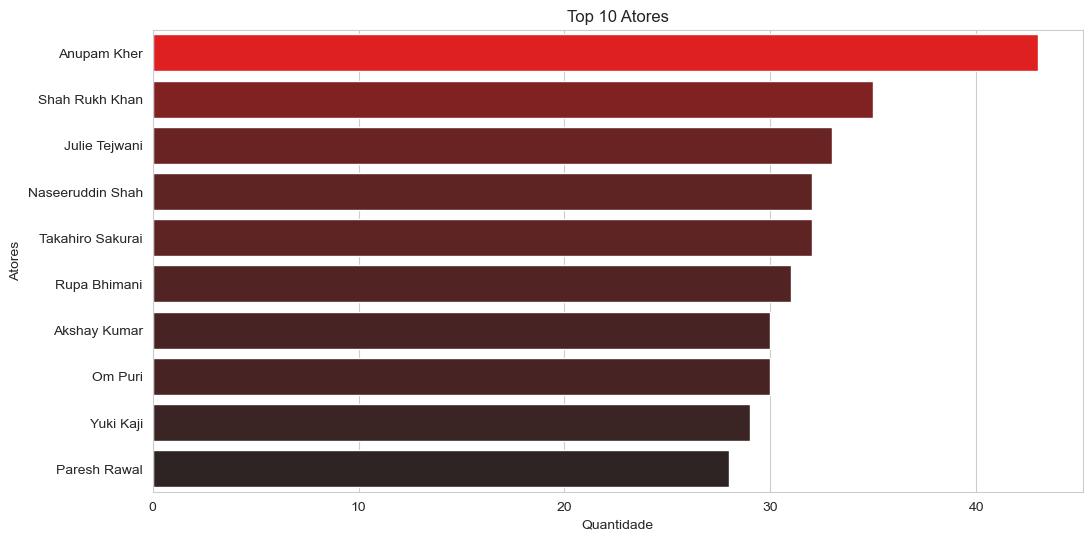

In [211]:
atores = df["cast"].str.split(', ').explode()
atores_qt = atores.value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=atores_qt.values, y=atores_qt.index,hue=atores_qt, palette="dark:red", legend=False)
plt.title("Top 10 Atores")
plt.xlabel("Quantidade")
plt.ylabel("Atores")
legend=False
plt.show()

## Top 10 Diretores com Mais Trabalhos

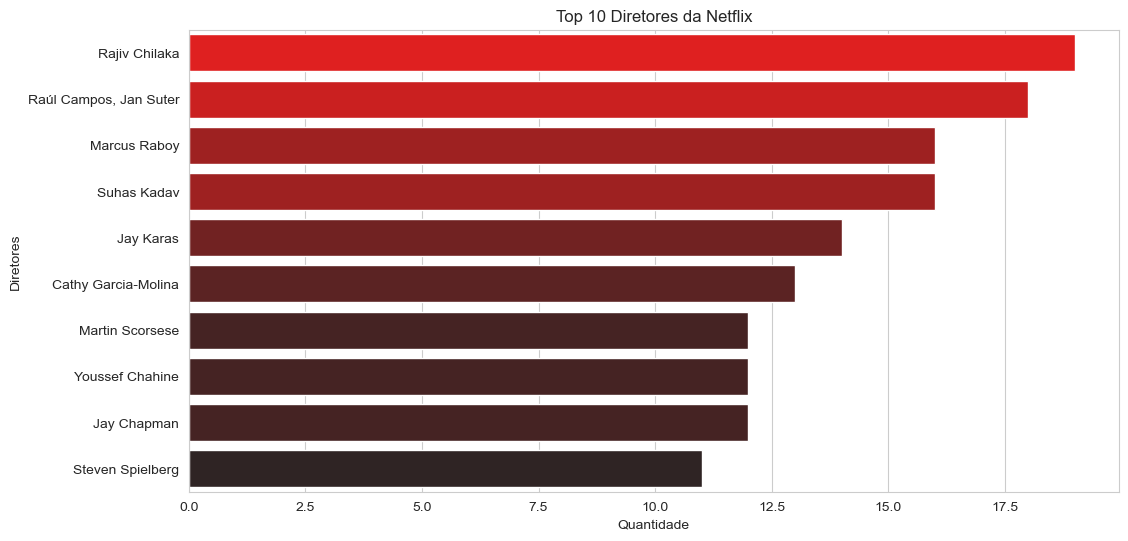

In [213]:
diretores = df["director"].value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(x= diretores.values, y= diretores.index, hue=diretores, palette="dark:red", legend=False)
plt.title("Top 10 Diretores da Netflix")
plt.xlabel("Quantidade")
plt.ylabel("Diretores")
plt.show()

## Ranking de Gêneros


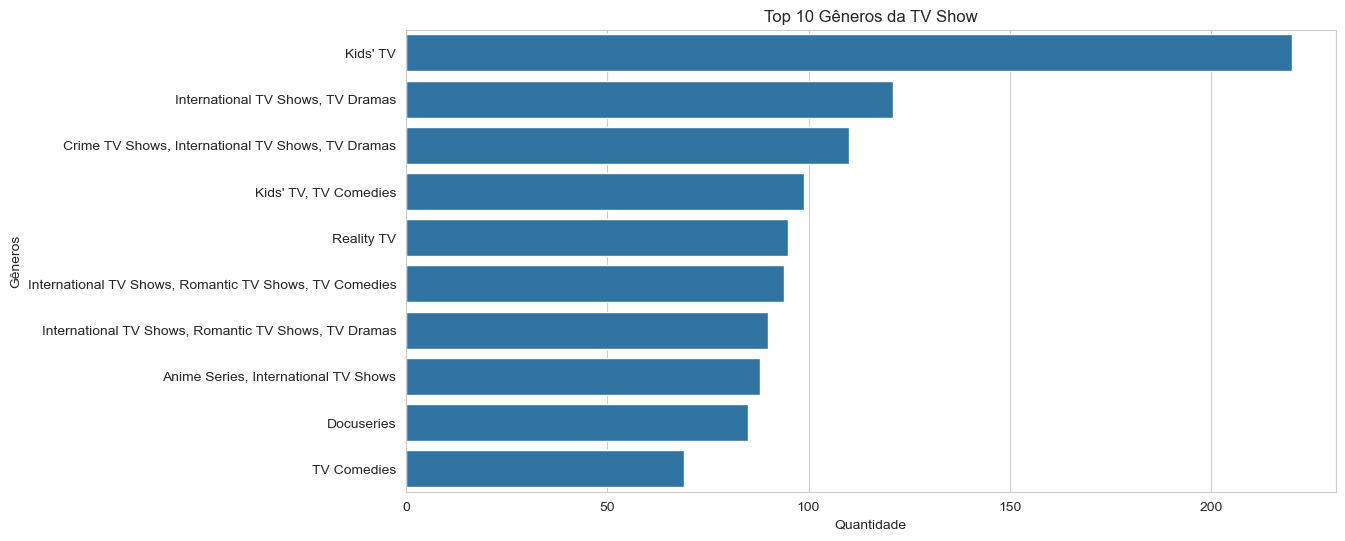

In [274]:
tv_generos = df[df["type"]=="TV Show"]["listed_in"].value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=tv_generos.values, y = tv_generos.index)
plt.title("Top 10 Gêneros da TV Show")
plt.xlabel("Quantidade")
plt.ylabel("Gêneros")
plt.show()


## Análise de Temporadas das Séries


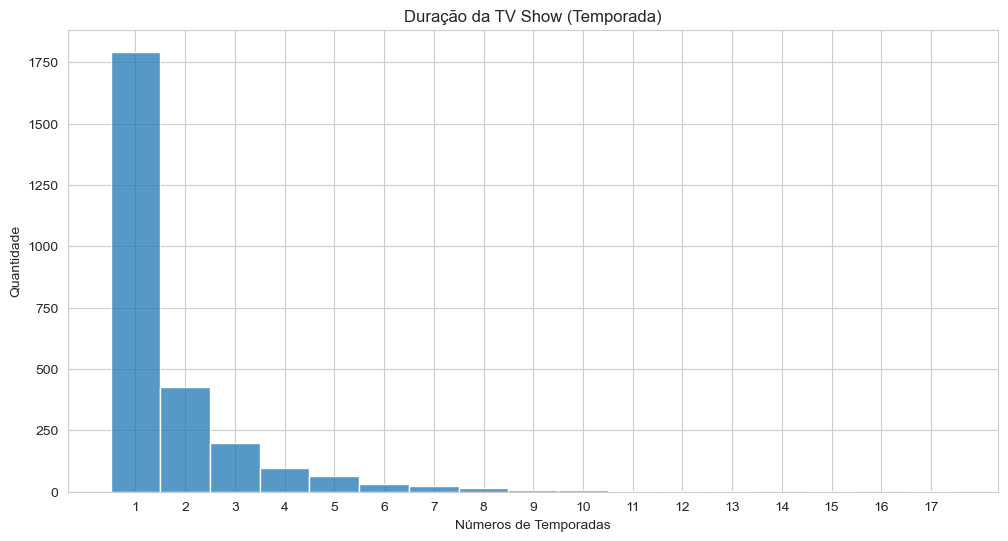

In [208]:
df["duracao_tv"] = df["duration"].str.extract(r"(\d+)").astype(float)
tv_temp = df[df["type"] == "TV Show"]
tv_temp = tv_temp.dropna(subset=["duracao_tv"])
tv_temp["duracao_tv"] = tv_temp["duracao_tv"].astype(int)
plt.figure(figsize=(12,6))
sns.histplot(tv_temp["duracao_tv"], bins=range(1, int(tv_temp["duracao_tv"].max()) + 2), discrete=True)
plt.xticks(range(1, tv_temp["duracao_tv"].max() + 1))
plt.title("Duração da TV Show (Temporada)")
plt.xlabel("Números de Temporadas")
plt.ylabel("Quantidade")
plt.show()

## Conclusão

1. **Crescimento de Séries:** A partir de 2015, houve um aumento significativo na adição de séries, embora o catálogo ainda seja predominantemente composto por filmes.

2. **Domínio Geográfico:** O catálogo é liderado pela produção dos Estados Unidos, seguido pela Índia, mostrando a forte presença americana e o crescimento de produções internacionais.

3. **Público-alvo:** A classificação indicativa que mais predomina é conteúdo adulto (TV-MA), indicando o foco da plataforma nesse segmento.

4. **Pico de Produção:** Houve um aumento significativo na produção de conteúdo entre 2017 e 2019, período de forte expansão da Netflix.

---

### 📊 Resumo Final

A Netflix mantém um catálogo **diversificado**, com **foco em conteúdo adulto** e **forte presença americana**. Contudo, observa-se um crescimento significativo em **produções internacionais** nos últimos anos, especialmente a partir de 2015, com destaque para o aumento de séries no catálogo.